In [121]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    fbeta_score, make_scorer, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier



In [66]:
# 1. Definir las rutas de los archivos CSV preprocesados
path_train = "dfFinalMA_Train/MA_TRAIN.csv"
path_test  = "dfFinalMA_Test/MA_Test.csv"

# 2. Cargar los datasets
df_train = pd.read_csv(path_train)
df_test  = pd.read_csv(path_test)

# 3. Verificación de carga
print("==============================================")
print("        DATASETS CARGADOS CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de Train: {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"Dimensiones de Test:  {df_test.shape[0]} filas, {df_test.shape[1]} columnas")

print("\n--- Tipos de datos en Train ---")
print(df_train.dtypes)

print("\n--- Primeras 5 filas de Train ---")
display(df_train.head())

        DATASETS CARGADOS CON ÉXITO           
Dimensiones de Train: 6375 filas, 15 columnas
Dimensiones de Test:  1608 filas, 15 columnas

--- Tipos de datos en Train ---
User_ID                       object
Age                            int64
Gender                        object
User_Archetype                object
Primary_Platform              object
Daily_Screen_Time_Hours      float64
Dominant_Content_Type         object
Activity_Type                 object
Late_Night_Usage                bool
Social_Comparison_Trigger       bool
Sleep_Duration_Hours         float64
GAD_7_Score                    int64
GAD_7_Severity                object
PHQ_9_Score                    int64
PHQ_9_Severity                object
dtype: object

--- Primeras 5 filas de Train ---


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-00061085,19,MALE,PASSIVE SCROLLER,FACEBOOK,4.0,NEWS/POLITICS,PASSIVE,True,False,5.8,8,MILD,8,MILD
1,U-00088ACC,20,MALE,PASSIVE SCROLLER,TIKTOK,4.0,NEWS/POLITICS,PASSIVE,True,False,4.2,10,MODERATE,7,MILD
2,U-000A7FEC,20,MALE,AVERAGE USER,INSTAGRAM,3.6,LIFESTYLE/FASHION,ACTIVE,False,True,6.9,10,MODERATE,0,NONE-MINIMAL
3,U-00228E6E,19,MALE,PASSIVE SCROLLER,YOUTUBE,3.1,LIFESTYLE/FASHION,PASSIVE,False,False,6.2,7,MILD,9,MILD
4,U-00262C0F,18,FEMALE,AVERAGE USER,LINKEDIN,2.4,EDUCATIONAL/TECH,ACTIVE,False,False,6.4,9,MILD,1,NONE-MINIMAL


In [67]:
# 1. Filtrar únicamente Moderate y Severe
df_train = df_train[df_train['PHQ_9_Severity'].isin(['MODERATELY SEVERE', 'SEVERE'])].copy()
df_test = df_test[df_test['PHQ_9_Severity'].isin(['MODERATELY SEVERE', 'SEVERE'])].copy()

# 2. Definir la variable objetivo
le = LabelEncoder()

df_train['PHQ_9_Severity'] = le.fit_transform(df_train['PHQ_9_Severity'])
df_test['PHQ_9_Severity'] = le.transform(df_test['PHQ_9_Severity'])

target_col = "PHQ_9_Severity"

columnas_a_dropear = [
    "User_ID",                 
    "GAD_7_Score",
    "GAD_7_Severity",
    "PHQ_9_Score",
]

# 3. Separar X (Características) e y (Variable Objetivo) para TRAIN
X_train = df_train.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_train = df_train[target_col]

# 4. Separar X e y para TEST
X_test = df_test.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_test = df_test[target_col]

# 5. Comprobación
print("==============================================")
print("        SEPARACIÓN Y LIMPIEZA COMPLETADA      ")
print("==============================================")
print(f"Dimensiones de X_train (Predictoras): {X_train.shape}")
print(f"Dimensiones de y_train (Objetivo):    {y_train.shape}")
print(f"Dimensiones de X_test (Predictoras):  {X_test.shape}")
print(f"Dimensiones de y_test (Objetivo):     {y_test.shape}")

print("\nColumnas que usará el modelo para aprender:")
print(list(X_train.columns))

        SEPARACIÓN Y LIMPIEZA COMPLETADA      
Dimensiones de X_train (Predictoras): (296, 10)
Dimensiones de y_train (Objetivo):    (296,)
Dimensiones de X_test (Predictoras):  (82, 10)
Dimensiones de y_test (Objetivo):     (82,)

Columnas que usará el modelo para aprender:
['Age', 'Gender', 'User_Archetype', 'Primary_Platform', 'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type', 'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours']


In [68]:
# 1. Identificar cuáles son las columnas numéricas
# Seleccionamos solo las columnas de tipo entero y decimal
columnas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

print(f"Se van a escalar las siguientes columnas numéricas:\n{list(columnas_numericas)}\n")

# 2. Inicializar el StandardScaler
scaler = StandardScaler()

# 3. AjustaR  y transformar 
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# ==========================================
# 5. Comprobación de que se hizo correctamente
# ==========================================
print("--- Comprobación en TRAIN ---")
print("La media de Train debería ser muy cercana a 0:")
print(X_train[columnas_numericas].mean().round(2))
print("\nLa desviación estándar de Train debería ser 1:")
print(X_train[columnas_numericas].std().round(2))

print("\n--- Primeras filas de X_train escalado ---")
display(X_train.head()) 

Se van a escalar las siguientes columnas numéricas:
['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours']

--- Comprobación en TRAIN ---
La media de Train debería ser muy cercana a 0:
Age                        0.0
Daily_Screen_Time_Hours    0.0
Sleep_Duration_Hours      -0.0
dtype: float64

La desviación estándar de Train debería ser 1:
Age                        1.0
Daily_Screen_Time_Hours    1.0
Sleep_Duration_Hours       1.0
dtype: float64

--- Primeras filas de X_train escalado ---


,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours
13,-1.004456,FEMALE,PASSIVE SCROLLER,TWITTER/X,-0.929464,SELF-HELP/MOTIVATION,PASSIVE,True,False,2.059537
52,2.588524,MALE,HYPER-CONNECTED,LINKEDIN,0.475582,ENTERTAINMENT/COMEDY,ACTIVE,True,False,-0.112751
64,0.792034,MALE,HYPER-CONNECTED,YOUTUBE,0.408675,GAMING,ACTIVE,True,False,-0.705193
70,0.792034,MALE,PASSIVE SCROLLER,TWITTER/X,0.542489,LIFESTYLE/FASHION,PASSIVE,True,False,-0.112751
86,-0.106211,MALE,HYPER-CONNECTED,INSTAGRAM,1.144651,LIFESTYLE/FASHION,ACTIVE,True,True,-0.112751


In [69]:
# 1. Definir qué columnas son categóricas
columnas_categoricas = ['Gender', 'User_Archetype', 'Primary_Platform', 'Dominant_Content_Type','Activity_Type']

# 2. Aplicar One-Hot Encoding a Train y Test
X_train_codificado = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test_codificado = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# 3. ALINEAR Train y Test
X_train_codificado, X_test_codificado = X_train_codificado.align(X_test_codificado, join='left', axis=1, fill_value=0)

print(f"Columnas finales para entrenar: {X_train_codificado.shape[1]}")

Columnas finales para entrenar: 21


In [70]:
print(df_train['PHQ_9_Severity'].value_counts())

PHQ_9_Severity
0    278
1     18
Name: count, dtype: int64


In [71]:
# 1. Definir el modelo base
logreg_model = LogisticRegression(
    random_state=46,
    max_iter=5000,
    class_weight='balanced'

)

# 2. Definir la parrilla de hiperparámetros que quieres probar
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

# 3. Configurar el GridSearch con Validación Cruzada (5 folds)
grid_search = GridSearchCV(
    estimator=logreg_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=2,
    n_jobs=-1,
    verbose=1
)

print("--- Iniciando búsqueda de hiperparámetros (Grid Search) ---")

grid_search.fit(X_train_codificado, y_train)

# 4. Ver los mejores resultados
print("\n==============================================")
print("       MEJORES HIPERPARÁMETROS ENCONTRADOS    ")
print("==============================================")
print(grid_search.best_params_)
print(f"Mejor F1 Weighted en Validación Cruzada: {grid_search.best_score_:.4f}")

--- Iniciando búsqueda de hiperparámetros (Grid Search) ---
Fitting 2 folds for each of 7 candidates, totalling 14 fits

       MEJORES HIPERPARÁMETROS ENCONTRADOS    
{'C': 100}
Mejor F1 Weighted en Validación Cruzada: 0.8030


       MÉTRICAS EN TEST (Regresión Logística)  
Accuracy  : 62.20%
Precision : 89.91%
Recall    : 62.20%
F1 Score  : 72.91%

                   precision    recall  f1-score   support

MODERATELY SEVERE       0.94      0.64      0.76        78
           SEVERE       0.03      0.25      0.06         4

         accuracy                           0.62        82
        macro avg       0.49      0.45      0.41        82
     weighted avg       0.90      0.62      0.73        82



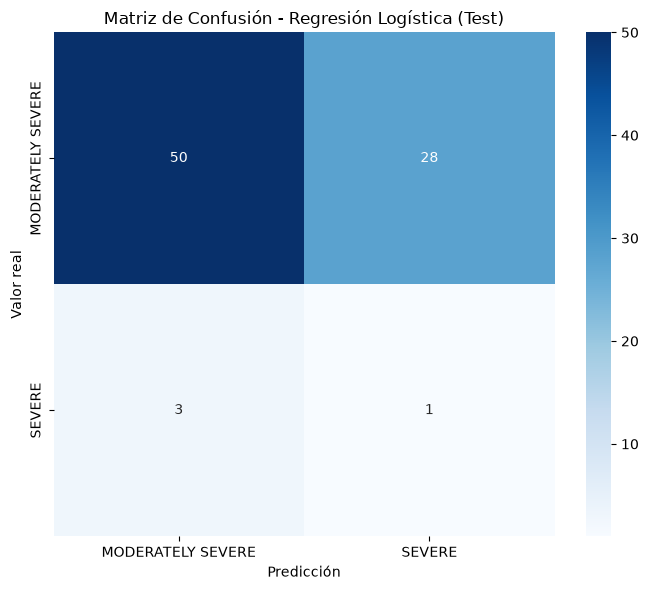

In [72]:
# 1. Tomar el mejor modelo encontrado por el GridSearch
best_model = grid_search.best_estimator_

# 2. Predecir sobre el set de TEST (nunca visto durante el entrenamiento/CV)
y_pred = best_model.predict(X_test_codificado)

# 3. Calcular métricas sobre el test set
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("==============================================")
print("       MÉTRICAS EN TEST (Regresión Logística)  ")
print("==============================================")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 4. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Regresión Logística (Test)')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# MÉTRICA F2
# ==========================================

f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)

# ==========================================
# PIPELINE
# ==========================================

pipeline = Pipeline([
    (
        'smote_tomek',
        SMOTETomek(
            random_state=46
        )
    ),
    (
        'model',
        XGBClassifier(
            random_state=46,
            eval_metric='logloss'
        )
    )
])

# ==========================================
# GRID SEARCH
# ==========================================

param_grid = {

    # SMOTETomek
    'smote_tomek__sampling_strategy': [
        0.2,
        0.3,
        0.4,
        0.5,
        0.6,
        0.7,
        0.8,
        1.0
    ],

    # XGBoost
    'model__n_estimators': [
        50,
        100,
        200
    ],

    'model__max_depth': [
        2,
        3,
        4
    ],

    'model__learning_rate': [
        0.01,
        0.05,
        0.1
    ],

    'model__subsample': [
        0.7,
        0.8,
        1.0
    ],

    'model__colsample_bytree': [
        0.7,
        0.8,
        1.0
    ]
}

# ==========================================
# CROSS VALIDATION
# ==========================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=46
)

# ==========================================
# GRIDSEARCH
# ==========================================

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# ==========================================
# ENTRENAMIENTO
# ==========================================

grid_search.fit(
    X_train_codificado,
    y_train
)

# ==========================================
# RESULTADOS
# ==========================================

print("==============================================")
print("       MEJORES HIPERPARÁMETROS")
print("==============================================")

print(grid_search.best_params_)

print(
    f"\nMejor F2 CV: "
    f"{grid_search.best_score_:.4f}"
)

Fitting 5 folds for each of 1944 candidates, totalling 9720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [50, 100, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(f..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.S

       OPTIMIZACIÓN DEL THRESHOLD
Threshold óptimo: 0.0332
Precision en ese punto: 0.0769
Recall en ese punto:    0.7500
F2 en ese punto:        0.2727

       MÉTRICAS EN TEST - XGBOOST
Threshold aplicado: 0.0332
Accuracy : 54.88%
Precision: 7.69%
Recall   : 75.00%
F1       : 13.95%
F2       : 27.27%

       CLASSIFICATION REPORT
              precision    recall  f1-score   support

   NO SEVERE       0.98      0.54      0.69        78
      SEVERE       0.08      0.75      0.14         4

    accuracy                           0.55        82
   macro avg       0.53      0.64      0.42        82
weighted avg       0.93      0.55      0.67        82



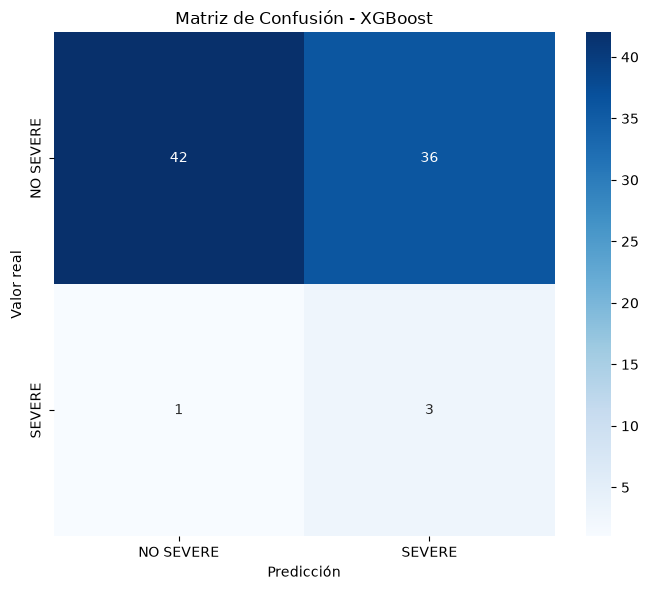

In [124]:
# ==========================================
# 1. TOMAR EL MEJOR MODELO DEL GRIDSEARCH
# ==========================================

best_model = grid_search.best_estimator_


# ==========================================
# 2. PROBABILIDADES DE SEVERE
# ==========================================

# Probabilidad de la clase positiva (SEVERE = 1)
y_probs = best_model.predict_proba(X_test_codificado)[:, 1]


# ==========================================
# 3. BUSCAR THRESHOLD
# ==========================================

precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    y_probs
)

# F2:
# F2 = 5 * precision * recall / (4 * precision + recall)

f2_scores = (
    5 * precisions[:-1] * recalls[:-1]
    / (
        4 * precisions[:-1]
        + recalls[:-1]
        + 1e-10
    )
)

# Threshold que maximiza F2
best_idx = np.argmax(f2_scores)
optimal_threshold = thresholds[best_idx]


print("==============================================")
print("       OPTIMIZACIÓN DEL THRESHOLD")
print("==============================================")
print(f"Threshold óptimo: {optimal_threshold:.4f}")
print(f"Precision en ese punto: {precisions[best_idx]:.4f}")
print(f"Recall en ese punto:    {recalls[best_idx]:.4f}")
print(f"F2 en ese punto:        {f2_scores[best_idx]:.4f}")


# ==========================================
# 4. PREDICCIÓN CON THRESHOLD
# ==========================================

y_pred = (
    y_probs >= optimal_threshold
).astype(int)


# ==========================================
# 5. MÉTRICAS
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

f2 = fbeta_score(
    y_test,
    y_pred,
    beta=2,
    zero_division=0
)


# ==========================================
# 6. RESULTADOS
# ==========================================

print("\n==============================================")
print("       MÉTRICAS EN TEST - XGBOOST")
print("==============================================")

print(f"Threshold aplicado: {optimal_threshold:.4f}")
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1       : {f1 * 100:.2f}%")
print(f"F2       : {f2 * 100:.2f}%")

print("\n==============================================")
print("       CLASSIFICATION REPORT")
print("==============================================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "NO SEVERE",
            "SEVERE"
        ],
        zero_division=0
    )
)


# ==========================================
# 7. MATRIZ DE CONFUSIÓN
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["NO SEVERE", "SEVERE"],
    yticklabels=["NO SEVERE", "SEVERE"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - XGBoost")

plt.tight_layout()
plt.show()

In [125]:
# ==========================================
# 1. Configurar Métrica F2 y Modelo Base
# ==========================================
f2_scorer = make_scorer(fbeta_score, beta=2)

xgb_model = XGBClassifier(
    random_state=46,
    eval_metric='logloss',
    scale_pos_weight=100
)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# ==========================================
# 2. Configurar y Ejecutar GridSearch (CV)
# ==========================================
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("--- Iniciando búsqueda de hiperparámetros ---")
grid_search.fit(X_train_codificado, y_train)

# ==========================================
# 3. RESULTADOS EXCLUSIVOS DE CROSS-VALIDATION
# ==========================================
print("\n==============================================")
print("       MEJORES HIPERPARÁMETROS (CV)          ")
print("==============================================")
print(grid_search.best_params_)
print(f"Mejor F2 Score en Validación Cruzada: {grid_search.best_score_:.4f}\n")

--- Iniciando búsqueda de hiperparámetros ---
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

       MEJORES HIPERPARÁMETROS (CV)          
{'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}
Mejor F2 Score en Validación Cruzada: 0.2706



       OPTIMIZACIÓN DEL THRESHOLD
Threshold óptimo: 0.8795
Precision en ese punto: 0.3333
Recall en ese punto:    0.5000
F2 en ese punto:        0.4545

       MÉTRICAS EN TEST - XGBOOST
Threshold aplicado: 0.8795
Accuracy : 92.68%
Precision: 33.33%
Recall   : 50.00%
F1       : 40.00%
F2       : 45.45%

       CLASSIFICATION REPORT
              precision    recall  f1-score   support

   NO SEVERE       0.97      0.95      0.96        78
      SEVERE       0.33      0.50      0.40         4

    accuracy                           0.93        82
   macro avg       0.65      0.72      0.68        82
weighted avg       0.94      0.93      0.93        82



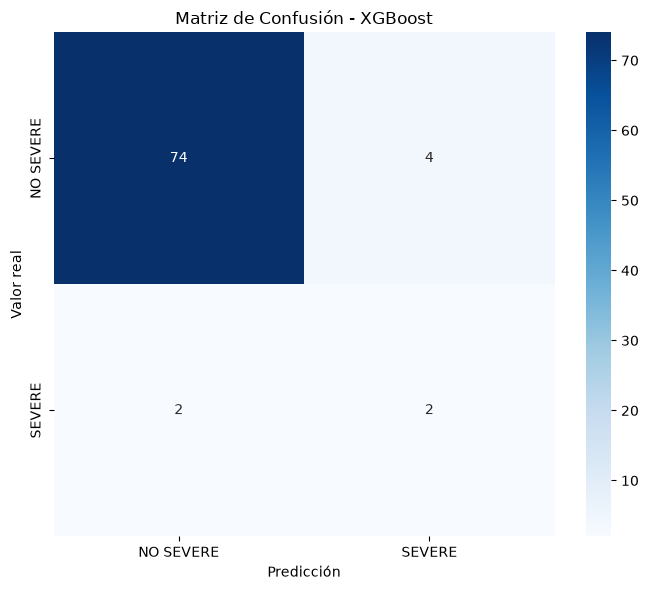

In [126]:
# ==========================================
# 1. TOMAR EL MEJOR MODELO DEL GRIDSEARCH
# ==========================================

best_model = grid_search.best_estimator_


# ==========================================
# 2. PROBABILIDADES DE SEVERE
# ==========================================

# Probabilidad de la clase positiva (SEVERE = 1)
y_probs = best_model.predict_proba(X_test_codificado)[:, 1]


# ==========================================
# 3. BUSCAR THRESHOLD
# ==========================================

precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    y_probs
)

# F2:
# F2 = 5 * precision * recall / (4 * precision + recall)

f2_scores = (
    5 * precisions[:-1] * recalls[:-1]
    / (
        4 * precisions[:-1]
        + recalls[:-1]
        + 1e-10
    )
)

# Threshold que maximiza F2
best_idx = np.argmax(f2_scores)
optimal_threshold = thresholds[best_idx]


print("==============================================")
print("       OPTIMIZACIÓN DEL THRESHOLD")
print("==============================================")
print(f"Threshold óptimo: {optimal_threshold:.4f}")
print(f"Precision en ese punto: {precisions[best_idx]:.4f}")
print(f"Recall en ese punto:    {recalls[best_idx]:.4f}")
print(f"F2 en ese punto:        {f2_scores[best_idx]:.4f}")


# ==========================================
# 4. PREDICCIÓN CON THRESHOLD
# ==========================================

y_pred = (
    y_probs >= optimal_threshold
).astype(int)


# ==========================================
# 5. MÉTRICAS
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

f2 = fbeta_score(
    y_test,
    y_pred,
    beta=2,
    zero_division=0
)


# ==========================================
# 6. RESULTADOS
# ==========================================

print("\n==============================================")
print("       MÉTRICAS EN TEST - XGBOOST")
print("==============================================")

print(f"Threshold aplicado: {optimal_threshold:.4f}")
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1       : {f1 * 100:.2f}%")
print(f"F2       : {f2 * 100:.2f}%")

print("\n==============================================")
print("       CLASSIFICATION REPORT")
print("==============================================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "NO SEVERE",
            "SEVERE"
        ],
        zero_division=0
    )
)


# ==========================================
# 7. MATRIZ DE CONFUSIÓN
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["NO SEVERE", "SEVERE"],
    yticklabels=["NO SEVERE", "SEVERE"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - XGBoost")

plt.tight_layout()
plt.show()